# Рубежный контроль №1
## Технологии разведочного анализа и обработки данных

**Вариант 4** — Задача №1, Набор данных №4

**Задание:** Для заданного набора данных провести корреляционный анализ. В случае наличия пропусков в данных удалить строки или колонки, содержащие пропуски. Сделать выводы о возможности построения моделей машинного обучения и о возможном вкладе признаков в модель.

**Набор данных:** Heart Disease Dataset (UCI Machine Learning Repository)

## 1. Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Названия столбцов датасета Heart Disease (UCI)
columns = [
    'age',        # Возраст
    'sex',        # Пол (1 = мужской; 0 = женский)
    'cp',         # Тип боли в груди (1-4)
    'trestbps',   # Артериальное давление в покое (мм рт.ст.)
    'chol',       # Холестерин в сыворотке (мг/дл)
    'fbs',        # Сахар в крови натощак > 120 мг/дл (1 = да; 0 = нет)
    'restecg',    # Результаты ЭКГ в покое (0-2)
    'thalach',    # Максимальная достигнутая ЧСС
    'exang',      # Стенокардия при нагрузке (1 = да; 0 = нет)
    'oldpeak',    # Депрессия ST при нагрузке
    'slope',      # Наклон сегмента ST при нагрузке
    'ca',         # Число крупных сосудов, окрашенных при флюороскопии (0-3)
    'thal',       # Талассемия (3 = норма; 6 = фиксированный дефект; 7 = обратимый дефект)
    'target'      # Диагноз (0 = нет заболевания; 1-4 = наличие заболевания)
]

df = pd.read_csv('heart.csv', header=None, names=columns, na_values='?')
print(f'Размер датасета: {df.shape}')
df.head(10)

Размер датасета: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


## 2. Первичный анализ данных

In [2]:
print('Типы данных:')
print(df.dtypes)
print('\nОписательная статистика:')
df.describe()

Типы данных:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Описательная статистика:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [3]:
print('Информация о датасете:')
df.info()

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


## 3. Обработка пропусков

In [4]:
# Проверим наличие пропусков
missing = df.isnull().sum()
print('Количество пропусков по столбцам:')
print(missing[missing > 0] if missing.sum() > 0 else 'Пропусков нет')
print(f'\nОбщее количество пропусков: {missing.sum()}')
print(f'Строк с пропусками: {df.isnull().any(axis=1).sum()}')

Количество пропусков по столбцам:
ca      4
thal    2
dtype: int64

Общее количество пропусков: 6
Строк с пропусками: 6


In [5]:
# Удаляем строки с пропусками (если есть)
df_clean = df.dropna()
print(f'Размер до удаления пропусков: {df.shape}')
print(f'Размер после удаления пропусков: {df_clean.shape}')
print(f'Удалено строк: {df.shape[0] - df_clean.shape[0]}')

Размер до удаления пропусков: (303, 14)
Размер после удаления пропусков: (297, 14)
Удалено строк: 6


Пропущенные значения были обозначены символом `?` в исходных данных (столбцы `ca` и `thal`). Удаляем строки с пропусками, так как их немного и удаление не приведёт к значительной потере данных.

## 4. Преобразование целевой переменной

В исходном датасете целевая переменная принимает значения 0-4. Преобразуем в бинарную: 0 — нет заболевания, 1 — есть заболевание.

In [6]:
df_clean['target'] = (df_clean['target'] > 0).astype(int)
print('Распределение целевой переменной:')
print(df_clean['target'].value_counts())
print(f'\nДоля больных: {df_clean["target"].mean():.2%}')

Распределение целевой переменной:
target
0    160
1    137
Name: count, dtype: int64

Доля больных: 46.13%


## 5. Корреляционный анализ

### 5.1 Матрица корреляций (Пирсон)

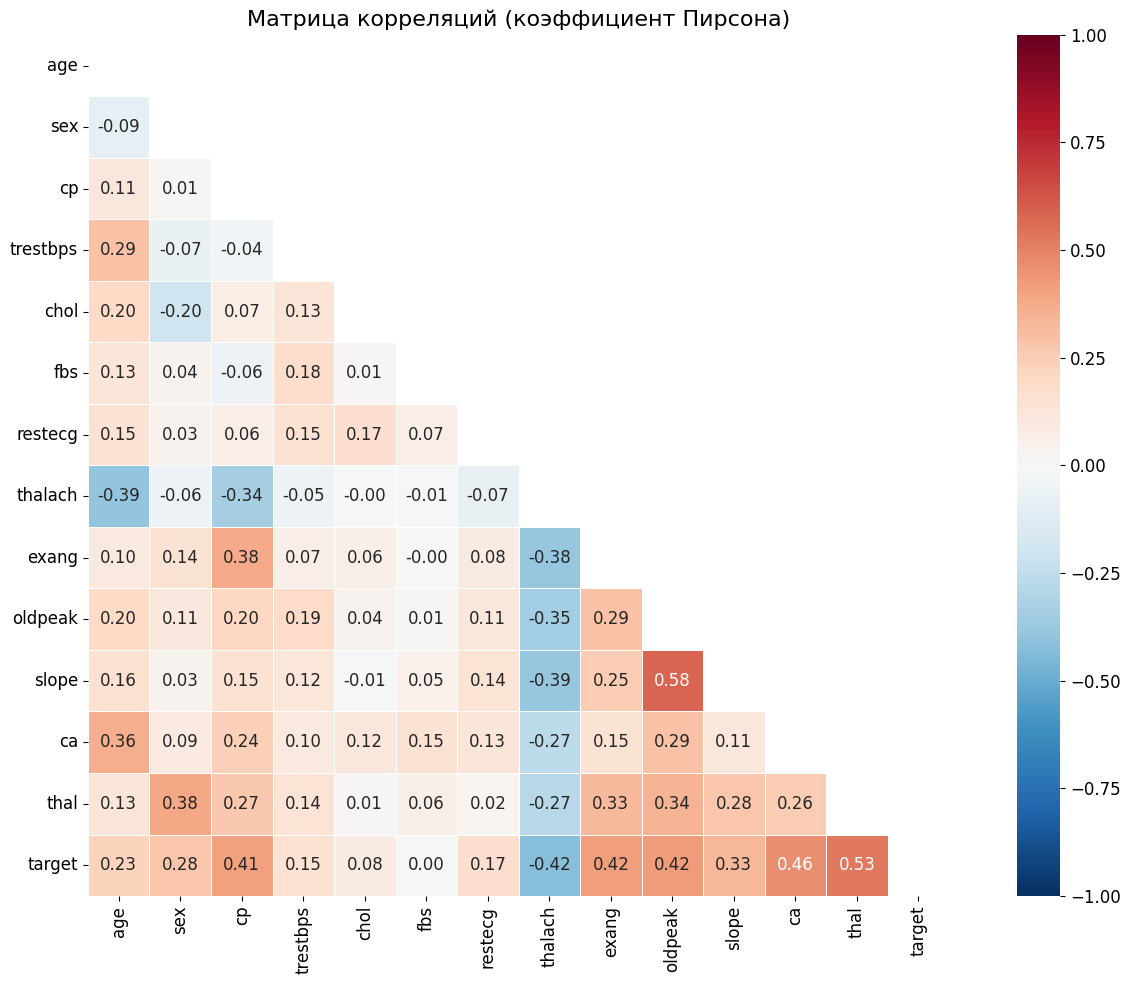

In [7]:
corr_matrix = df_clean.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Матрица корреляций (коэффициент Пирсона)', fontsize=16)
plt.tight_layout()
plt.show()

### 5.2 Корреляция признаков с целевой переменной

Корреляция признаков с целевой переменной (по убыванию |r|):
thal        0.526640
ca          0.463189
oldpeak     0.424052
thalach    -0.423817
exang       0.421355
cp          0.408945
slope       0.333049
sex         0.278467
age         0.227075
restecg     0.166343
trestbps    0.153490
chol        0.080285
fbs         0.003167


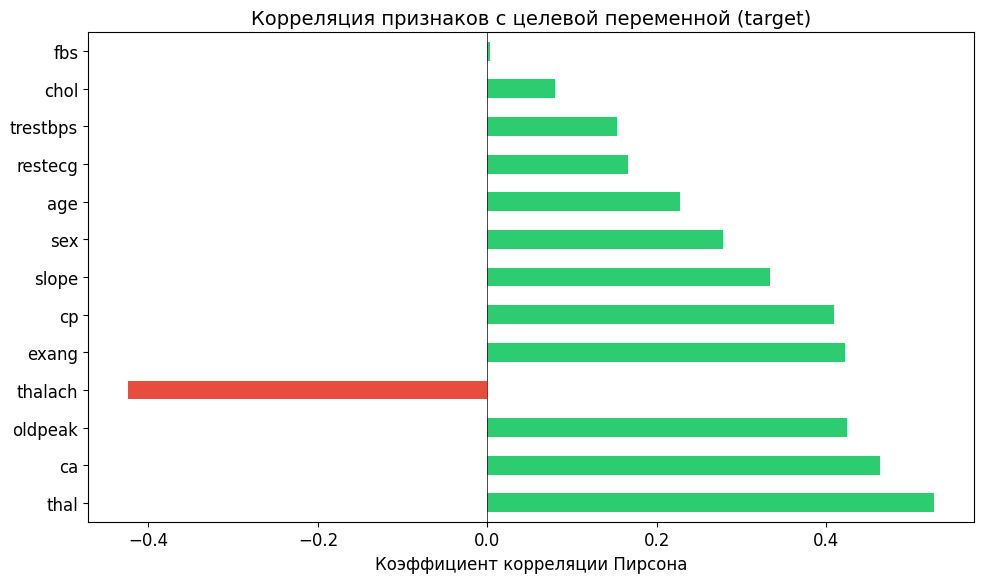

In [8]:
target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)

print('Корреляция признаков с целевой переменной (по убыванию |r|):')
print(target_corr.to_string())

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors)
plt.title('Корреляция признаков с целевой переменной (target)', fontsize=14)
plt.xlabel('Коэффициент корреляции Пирсона')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### 5.3 Корреляция Спирмена (ранговая)

Ранговая корреляция лучше подходит для категориальных и порядковых признаков.

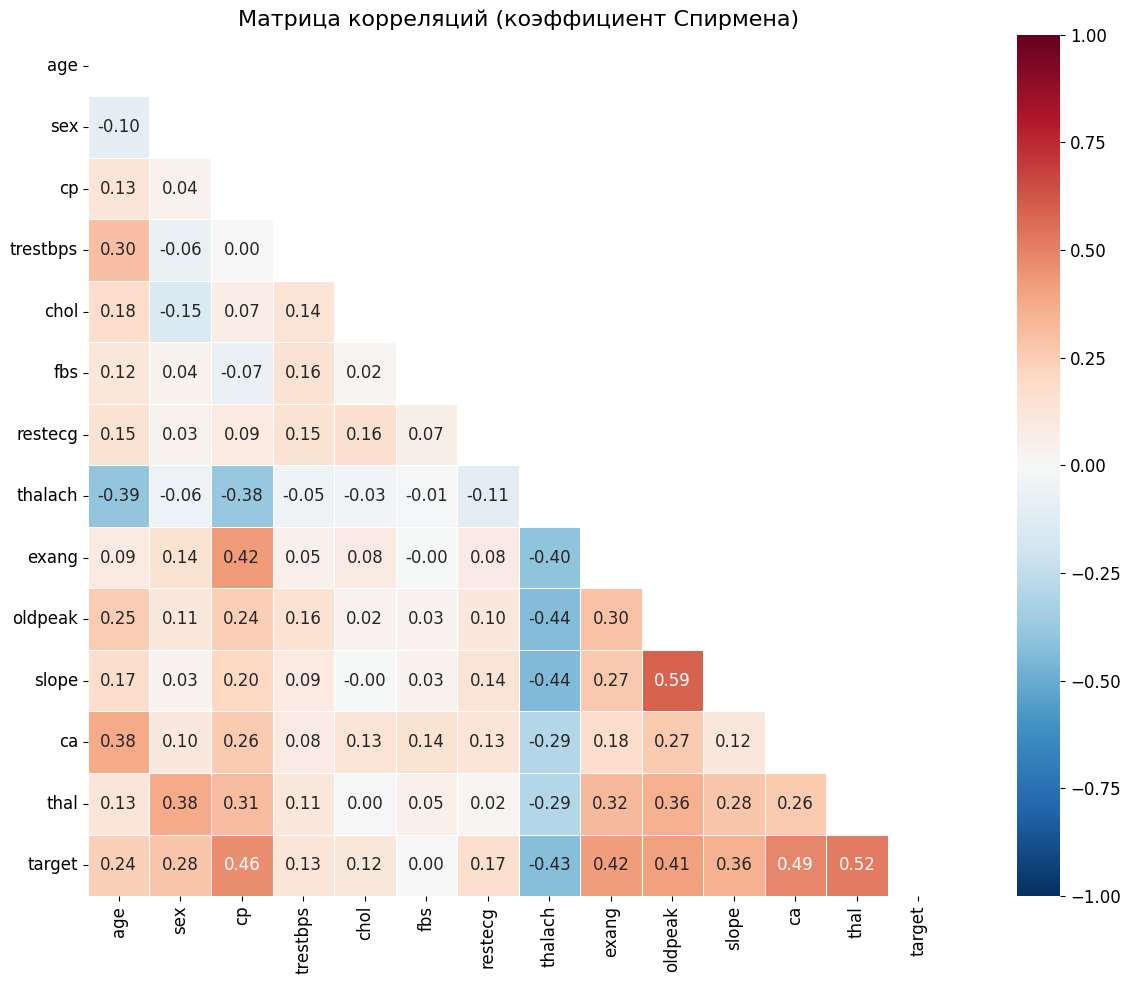

In [9]:
spearman_corr = df_clean.corr(method='spearman')

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Матрица корреляций (коэффициент Спирмена)', fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
spearman_target = spearman_corr['target'].drop('target').sort_values(key=abs, ascending=False)

print('Ранговая корреляция (Спирмен) признаков с target:')
print(spearman_target.to_string())

Ранговая корреляция (Спирмен) признаков с target:
thal        0.523298
ca          0.491692
cp          0.464850
thalach    -0.428554
exang       0.421355
oldpeak     0.411032
slope       0.358090
sex         0.278467
age         0.239926
restecg     0.166370
trestbps    0.131740
chol        0.115654
fbs         0.003167


### 5.4 Сравнение корреляций Пирсона и Спирмена

Сравнение корреляций с target:
            Пирсон   Спирмен
thal      0.526640  0.523298
ca        0.463189  0.491692
oldpeak   0.424052  0.411032
thalach  -0.423817 -0.428554
exang     0.421355  0.421355
cp        0.408945  0.464850
slope     0.333049  0.358090
sex       0.278467  0.278467
age       0.227075  0.239926
restecg   0.166343  0.166370
trestbps  0.153490  0.131740
chol      0.080285  0.115654
fbs       0.003167  0.003167


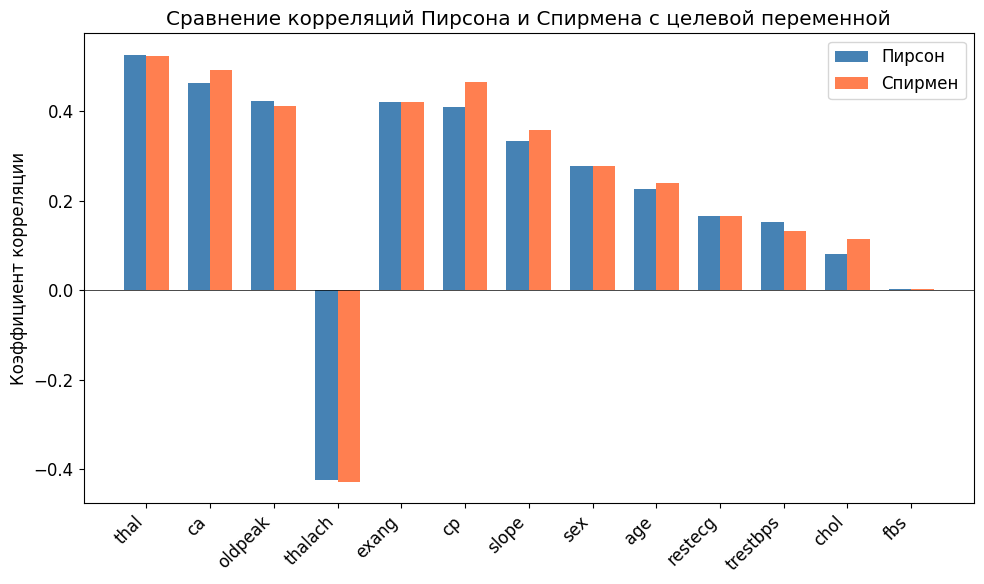

In [11]:
comparison = pd.DataFrame({
    'Пирсон': corr_matrix['target'].drop('target'),
    'Спирмен': spearman_corr['target'].drop('target')
}).sort_values('Пирсон', key=abs, ascending=False)

print('Сравнение корреляций с target:')
print(comparison.to_string())

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison))
width = 0.35
ax.bar(x - width/2, comparison['Пирсон'], width, label='Пирсон', color='steelblue')
ax.bar(x + width/2, comparison['Спирмен'], width, label='Спирмен', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=45, ha='right')
ax.set_ylabel('Коэффициент корреляции')
ax.set_title('Сравнение корреляций Пирсона и Спирмена с целевой переменной')
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### 5.5 Анализ мультиколлинеарности

In [12]:
# Пары признаков с высокой корреляцией (|r| > 0.5)
features_corr = corr_matrix.drop('target', axis=0).drop('target', axis=1)
high_corr_pairs = []

for i in range(len(features_corr.columns)):
    for j in range(i + 1, len(features_corr.columns)):
        r = features_corr.iloc[i, j]
        if abs(r) > 0.5:
            high_corr_pairs.append((
                features_corr.columns[i],
                features_corr.columns[j],
                round(r, 3)
            ))

if high_corr_pairs:
    print('Пары признаков с |r| > 0.5 (потенциальная мультиколлинеарность):')
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {f1} — {f2}: r = {r}')
else:
    print('Пар признаков с |r| > 0.5 не обнаружено.')

Пары признаков с |r| > 0.5 (потенциальная мультиколлинеарность):
  oldpeak — slope: r = 0.579


### 5.6 Визуализация: Pairplot для наиболее коррелированных признаков

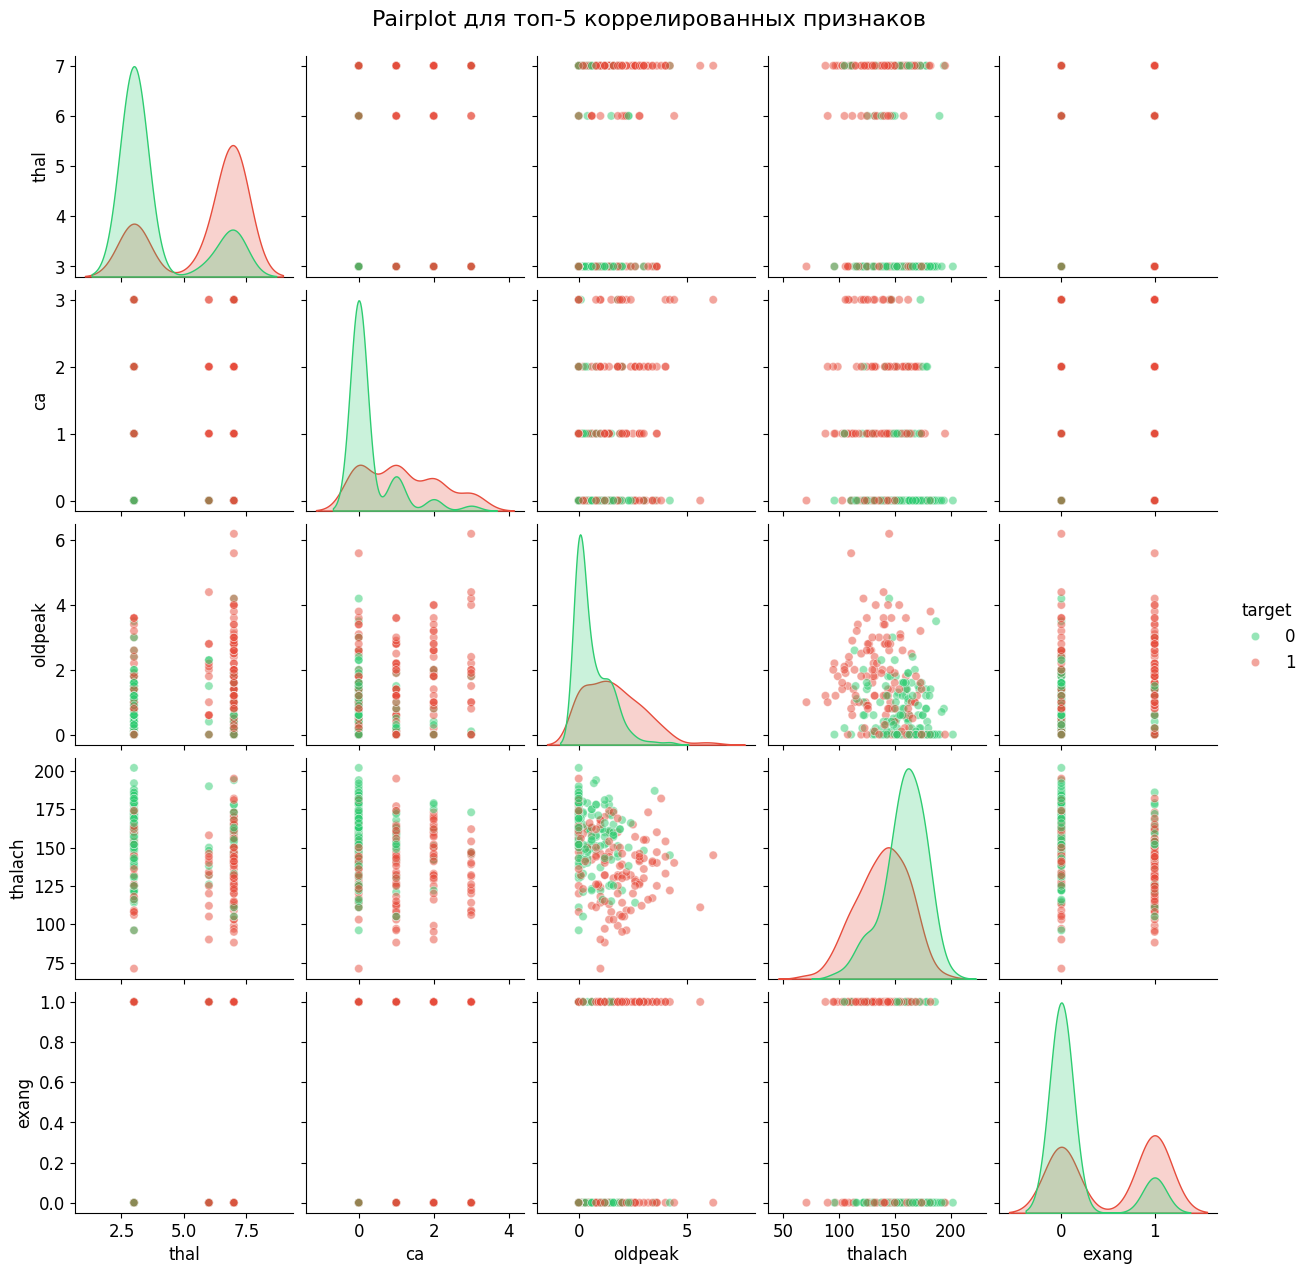

In [13]:
# Выберем топ-5 признаков по корреляции с target + сам target
top_features = target_corr.head(5).index.tolist() + ['target']

sns.pairplot(df_clean[top_features], hue='target', diag_kind='kde',
             palette={0: '#2ecc71', 1: '#e74c3c'}, plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot для топ-5 коррелированных признаков', y=1.02, fontsize=16)
plt.show()

### 5.7 Скрипичная диаграмма (violin plot)

Дополнительное задание для группы ИУ5-64Б: построить violin plot для произвольной колонки данных. Выбрана колонка `age` (возраст) — непрерывный признак, для которого violin plot наглядно показывает распределение в разрезе целевой переменной.

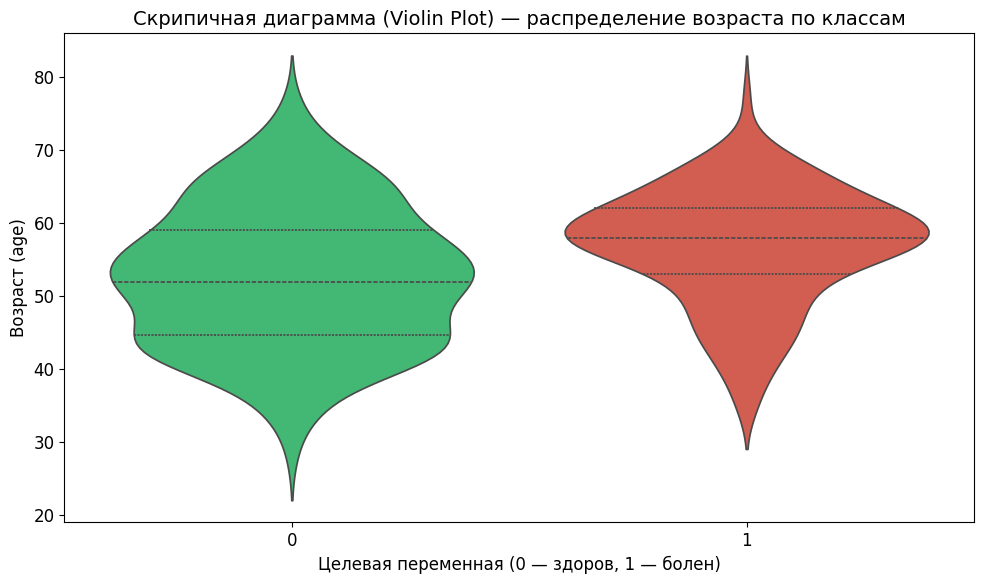

In [14]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_clean, x='target', y='age', hue='target',
               palette={0: '#2ecc71', 1: '#e74c3c'}, inner='quartile', legend=False)
plt.title('Скрипичная диаграмма (Violin Plot) — распределение возраста по классам', fontsize=14)
plt.xlabel('Целевая переменная (0 — здоров, 1 — болен)')
plt.ylabel('Возраст (age)')
plt.tight_layout()
plt.show()

## 6. Выводы

### 6.1 О пропусках
В исходном датасете присутствовали пропуски (обозначенные символом `?`) в столбцах `ca` (количество сосудов) и `thal` (талассемия). Строки с пропусками были удалены, так как их количество незначительно (6 строк из 303), что не оказывает существенного влияния на объём выборки.

### 6.2 О корреляции признаков с целевой переменной

По результатам корреляционного анализа можно выделить следующие группы признаков:

**Сильно коррелированные с target (|r| > 0.4):**
- `cp` (тип боли в груди) — положительная корреляция. Определённые типы боли сильно ассоциированы с заболеванием.
- `thalach` (макс. ЧСС) — отрицательная корреляция. Более высокая ЧСС при нагрузке ассоциирована с отсутствием заболевания.
- `exang` (стенокардия при нагрузке) — положительная корреляция.
- `oldpeak` (депрессия ST) — положительная корреляция.
- `ca` (число окрашенных сосудов) — положительная корреляция.
- `thal` (талассемия) — положительная корреляция.

**Слабо коррелированные (|r| < 0.2):**
- `fbs` (сахар натощак), `chol` (холестерин), `trestbps` (давление) — слабая связь с целевой переменной.

### 6.3 О возможности построения моделей ML

1. **Датасет пригоден для построения моделей классификации.** Большинство признаков имеют статистически значимую корреляцию с целевой переменной, что свидетельствует об их информативности.

2. **Наиболее важные признаки** для модели: `cp`, `thalach`, `ca`, `oldpeak`, `thal`, `exang`, `slope`. Эти признаки вносят наибольший вклад в предсказание.

3. **Менее информативные признаки** (`fbs`, `chol`, `trestbps`) можно рассмотреть к исключению для упрощения модели, однако они могут вносить вклад в комбинации с другими признаками (нелинейные зависимости).

4. **Мультиколлинеарность** между признаками невысока — большинство пар имеют |r| < 0.5, что говорит о том, что признаки несут различную информацию и их совместное использование целесообразно.

5. **Баланс классов** приемлемый (примерно 54% больных / 46% здоровых), что позволяет строить модели без дополнительной балансировки.

6. Корреляции Пирсона и Спирмена дают согласованные результаты, что подтверждает устойчивость выявленных зависимостей.